In [1]:
!pip install sentence-transformers
!pip install pdfplumber
!pip install python-docx
!pip install nltk

In [2]:
import os
import pdfplumber
import docx
import pandas as pd
import numpy as np
import nltk
import re

from google.colab import files
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# Create folders

os.makedirs("resumes", exist_ok=True)
os.makedirs("job_description", exist_ok=True)

print("Upload Resume Files (PDF/DOCX)")
uploaded_resumes = files.upload()

for file_name in uploaded_resumes.keys():
    os.rename(file_name, f"resumes/{file_name}")

print("Resume Upload Complete")

Upload Resume Files (PDF/DOCX)


Saving Neha_Asudani_Data_Analyst_Resume_251215_235433.pdf to Neha_Asudani_Data_Analyst_Resume_251215_235433.pdf
Resume Upload Complete


In [4]:
print("Upload Job Description File")

uploaded_jd = files.upload()

for file_name in uploaded_jd.keys():
    os.rename(file_name, f"job_description/{file_name}")

print("Job Description Upload Complete")

Upload Job Description File


Saving Job Description.pdf to Job Description.pdf
Job Description Upload Complete


In [5]:
def extract_text_from_pdf(file_path):
    text = ""

    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            extracted = page.extract_text()

            if extracted:
                text += extracted + " "

    return text


def extract_text_from_docx(file_path):
    doc = docx.Document(file_path)

    text = []

    for para in doc.paragraphs:
        text.append(para.text)

    return " ".join(text)


def extract_text(file_path):

    if file_path.endswith(".pdf"):
        return extract_text_from_pdf(file_path)

    elif file_path.endswith(".docx"):
        return extract_text_from_docx(file_path)

    elif file_path.endswith(".txt"):
        with open(file_path, "r", encoding="utf-8") as f:
            return f.read()

    return ""

In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [13]:
resume_texts = {}
resume_names = []

for file_name in os.listdir("resumes"):

    file_path = os.path.join("resumes", file_name)

    raw_text = extract_text(file_path)

    cleaned_text = preprocess_text(raw_text)

    resume_texts[file_name] = cleaned_text

    resume_names.append(file_name)

print("Resumes Loaded Successfully")

Resumes Loaded Successfully


In [8]:
jd_text = ""

for file_name in os.listdir("job_description"):

    file_path = os.path.join("job_description", file_name)

    raw_text = extract_text(file_path)

    jd_text += raw_text

jd_text = preprocess_text(jd_text)

print("Job Description Loaded")

Job Description Loaded


In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence-BERT Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT Model Loaded


In [14]:
jd_embedding = model.encode([jd_text])

results = []

for resume_name, resume_text in resume_texts.items():

    resume_embedding = model.encode([resume_text])

    similarity_score = cosine_similarity(
        jd_embedding,
        resume_embedding
    )[0][0]

    results.append({
        "Candidate": resume_name,
        "Match Score": round(similarity_score * 100, 2)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Match Score",
    ascending=False
)

results_df["Rank"] = range(
    1,
    len(results_df) + 1
)

results_df

,Candidate,Match Score,Rank
0,Rajath S Bhushan.pdf,69.760002,1
1,Neha_Asudani_Data_Analyst_Resume_251215_235433...,63.139999,2


In [11]:
results_df.to_csv(
    "ranked_candidates.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully


In [15]:
skills_database = [

    # Programming
    "python", "java", "c++", "sql", "r", "scala",

    # AI / ML / DS
    "machine learning",
    "deep learning",
    "nlp",
    "natural language processing",
    "data science",
    "artificial intelligence",
    "computer vision",

    # Libraries
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "keras",
    "pytorch",
    "matplotlib",
    "seaborn",

    # Big Data / Cloud
    "aws",
    "azure",
    "gcp",
    "spark",
    "hadoop",

    # Databases
    "mysql",
    "postgresql",
    "mongodb",

    # DevOps / MLOps
    "docker",
    "kubernetes",
    "mlops",

    # Tools
    "git",
    "github",
    "power bi",
    "tableau",
    "excel"
]

In [16]:
def extract_skills(text, skills_db):

    found_skills = set()

    text = text.lower()

    for skill in skills_db:

        if skill.lower() in text:
            found_skills.add(skill)

    return found_skills

In [17]:
jd_skills = extract_skills(
    jd_text,
    skills_database
)

print("Skills Found in JD:")
print(jd_skills)

Skills Found in JD:
{'r', 'machine learning', 'data science', 'python', 'azure'}


In [18]:
results = []

jd_embedding = model.encode([jd_text])

for resume_name, resume_text in resume_texts.items():

    # Embedding similarity
    resume_embedding = model.encode([resume_text])

    similarity_score = cosine_similarity(
        jd_embedding,
        resume_embedding
    )[0][0]

    # Skill extraction
    resume_skills = extract_skills(
        resume_text,
        skills_database
    )

    matched_skills = jd_skills.intersection(
        resume_skills
    )

    missing_skills = jd_skills.difference(
        resume_skills
    )

    results.append({
        "Candidate": resume_name,
        "Match Score":
            round(similarity_score * 100, 2),

        "Matched Skills":
            ", ".join(sorted(matched_skills)),

        "Missing Skills":
            ", ".join(sorted(missing_skills))
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Match Score",
    ascending=False
)

results_df["Rank"] = range(
    1,
    len(results_df)+1
)

results_df

,Candidate,Match Score,Matched Skills,Missing Skills,Rank
0,Rajath S Bhushan.pdf,69.760002,"azure, data science, machine learning, python, r",,1
1,Neha_Asudani_Data_Analyst_Resume_251215_235433...,63.139999,"python, r","azure, data science, machine learning",2


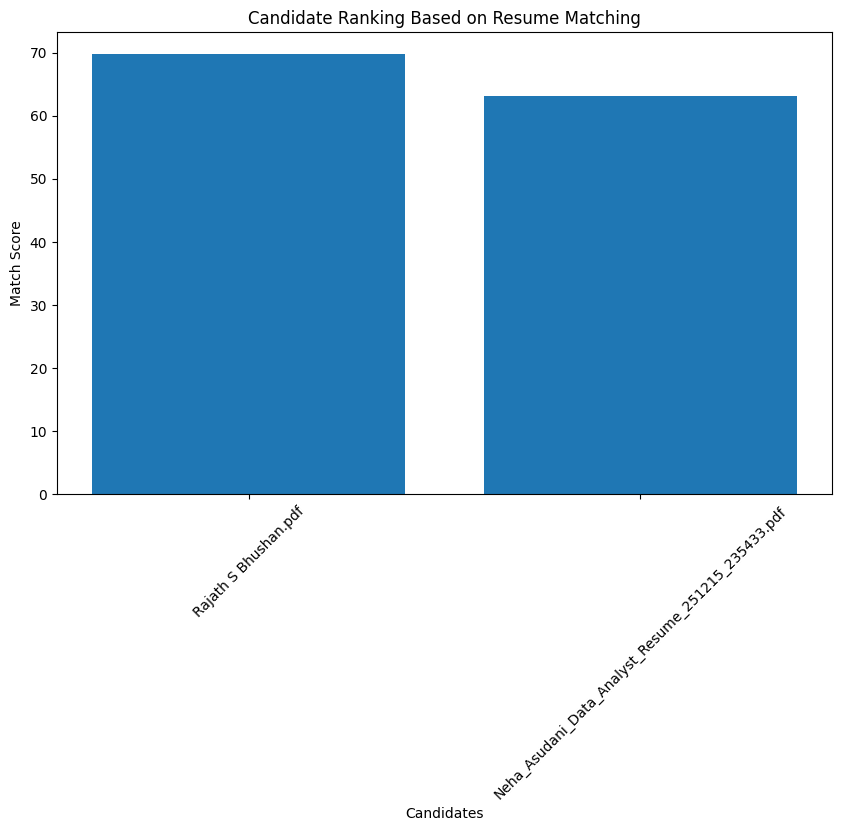

In [19]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Candidate"],
    results_df["Match Score"]
)

plt.xticks(rotation=45)

plt.xlabel("Candidates")
plt.ylabel("Match Score")

plt.title(
    "Candidate Ranking Based on Resume Matching"
)

plt.show()

In [20]:
results_df.to_csv(
    "ranked_candidates.csv",
    index=False
)

print(
    "CSV saved successfully"
)

CSV saved successfully


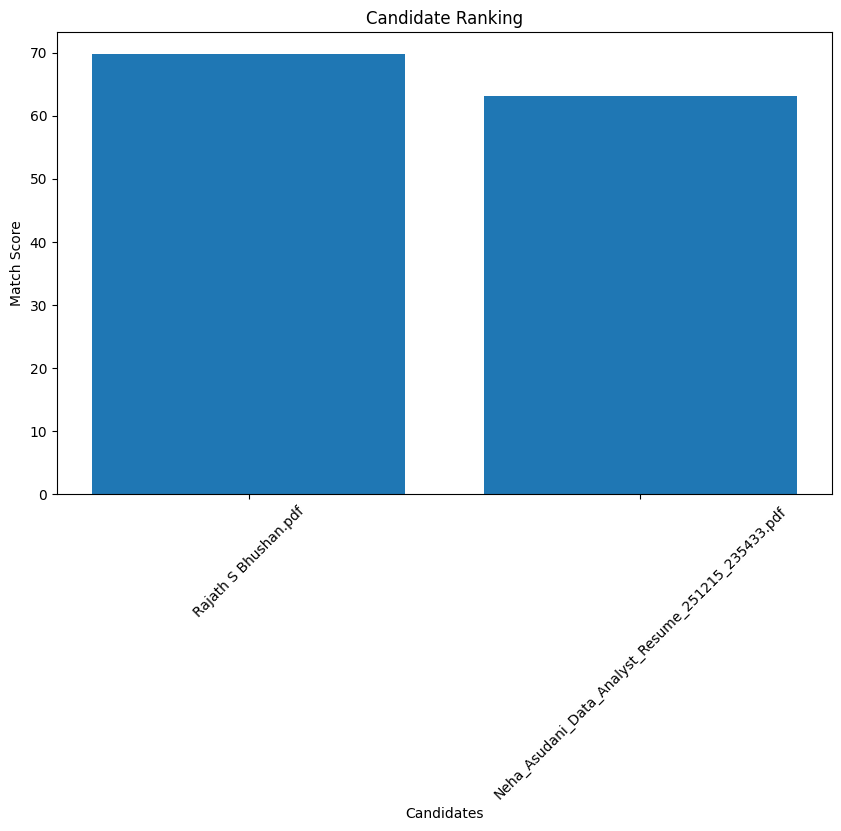

Chart saved successfully


In [21]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Candidate"],
    results_df["Match Score"]
)

plt.xticks(rotation=45)

plt.xlabel("Candidates")
plt.ylabel("Match Score")

plt.title(
    "Candidate Ranking"
)

plt.savefig(
    "ranking_chart.png"
)

plt.show()

print(
    "Chart saved successfully"
)